In [1]:
from pathlib import Path
import pandas as pd
import json

PROJECT_ROOT = Path.cwd().parent.parent
MODEL_RUNS_DIR = PROJECT_ROOT / "results" / "model_runs"

final_run_dirs = sorted(MODEL_RUNS_DIR.glob("random_forest_final_*"))
latest_run_dir = final_run_dirs[-1]

print("Latest final RF run:")
print(latest_run_dir)

test_metrics_file = latest_run_dir / "test_metrics.csv"
threshold_file = latest_run_dir / "threshold_sweep.csv"
importance_file = latest_run_dir / "permutation_importance.csv"
best_params_file = latest_run_dir / "best_params.json"
predictions_file = latest_run_dir / "test_predictions.csv"

print("\nExists?")
for f in [test_metrics_file, threshold_file, importance_file, best_params_file, predictions_file]:
    print(f.name, "->", f.exists())

test_metrics_df = pd.read_csv(test_metrics_file)
threshold_df = pd.read_csv(threshold_file)
permutation_importance_df = pd.read_csv(importance_file)

with open(best_params_file, "r") as f:
    best_params = json.load(f)

test_metrics_df

Latest final RF run:
c:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\random_forest_final_final_refit_test_eval_2026_03_20_20260320_135505

Exists?
test_metrics.csv -> True
threshold_sweep.csv -> True
permutation_importance.csv -> True
best_params.json -> True
test_predictions.csv -> True


,model_name,run_id,search_scoring,n_train_rows,n_test_rows,train_positive_rate,test_positive_rate,test_roc_auc,test_aucpr,test_log_loss,...,test_accuracy_at_0p10,test_recall_at_0p10,test_f1_at_0p10,test_accuracy_at_0p15,test_recall_at_0p15,test_f1_at_0p15,predicted_positive_rate_at_0p10,predicted_positive_rate_at_0p15,best_inner_cv_score,best_params_json
0,random_forest_final,random_forest_final_final_refit_test_eval_2026...,neg_log_loss,10461,2616,0.108594,0.129587,0.66052,0.247726,0.366166,...,0.478976,0.752212,0.27229,0.78211,0.389381,0.316547,0.586391,0.18922,-0.326626,"{""classifier__bootstrap"": true, ""classifier__c..."


In [2]:
oof_reference_rf = pd.DataFrame([{
    "model_name": "random_forest_oof_reference",
    "roc_auc": 0.649478,
    "aucpr": 0.183600,
    "log_loss": 0.329423,
    "brier": 0.093914,
    "ece": 0.001278,
    "f1_at_0p10": 0.248204,
    "recall_at_0p10": 0.669014,
}])

final_test_summary = pd.DataFrame([{
    "model_name": "random_forest_final_test",
    "roc_auc": test_metrics_df.loc[0, "test_roc_auc"],
    "aucpr": test_metrics_df.loc[0, "test_aucpr"],
    "log_loss": test_metrics_df.loc[0, "test_log_loss"],
    "brier": test_metrics_df.loc[0, "test_brier"],
    "ece": test_metrics_df.loc[0, "test_ece"],
    "f1_at_0p10": test_metrics_df.loc[0, "test_f1_at_0p10"],
    "recall_at_0p10": test_metrics_df.loc[0, "test_recall_at_0p10"],
}])

pd.concat([oof_reference_rf, final_test_summary], ignore_index=True)

,model_name,roc_auc,aucpr,log_loss,brier,ece,f1_at_0p10,recall_at_0p10
0,random_forest_oof_reference,0.649478,0.183600,0.329423,0.093914,0.001278,0.248204,0.669014
1,random_forest_final_test,0.660520,0.247726,0.366166,0.107828,0.008333,0.272290,0.752212


In [3]:
threshold_df

,threshold,accuracy,recall,f1,predicted_positive_rate
0,0.05,0.136850,1.000000,0.230926,0.992737
1,0.10,0.478976,0.752212,0.272290,0.586391
2,0.15,0.782110,0.389381,0.316547,0.189220
3,0.20,0.831422,0.250737,0.278232,0.103976
4,0.25,0.861621,0.109145,0.169725,0.037080
5,0.30,0.870413,0.000000,0.000000,0.000000


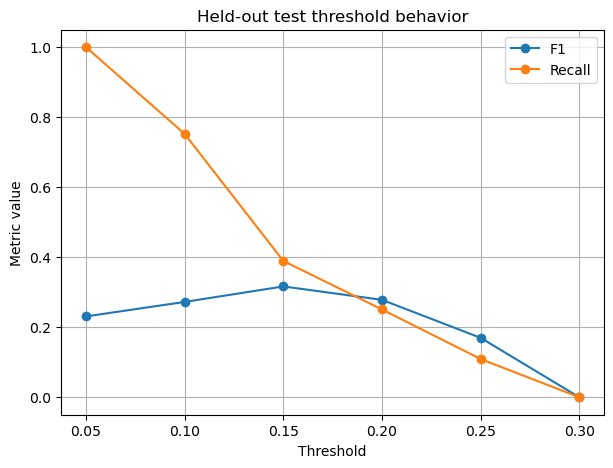

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Held-out test threshold behavior")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
permutation_importance_df.head(20)

,feature,importance_mean,importance_std
0,geolprov_interior_platform,0.002015,0.000695
1,socioeco_frac_housing_burden,0.001471,0.000706
2,mean_uranium,0.001429,0.000365
3,socioeco_median_income,0.001191,0.000483
4,longitude,0.001140,0.000304
5,hous_frac_type_single_detached,0.001108,0.000411
6,socioeco_frac_high_income,0.001000,0.000389
7,rxtp_sedimentary_rocks,0.000984,0.000295
8,hous_median_value,0.000962,0.000345
9,rxtp_intrusive_rocks,0.000863,0.000304


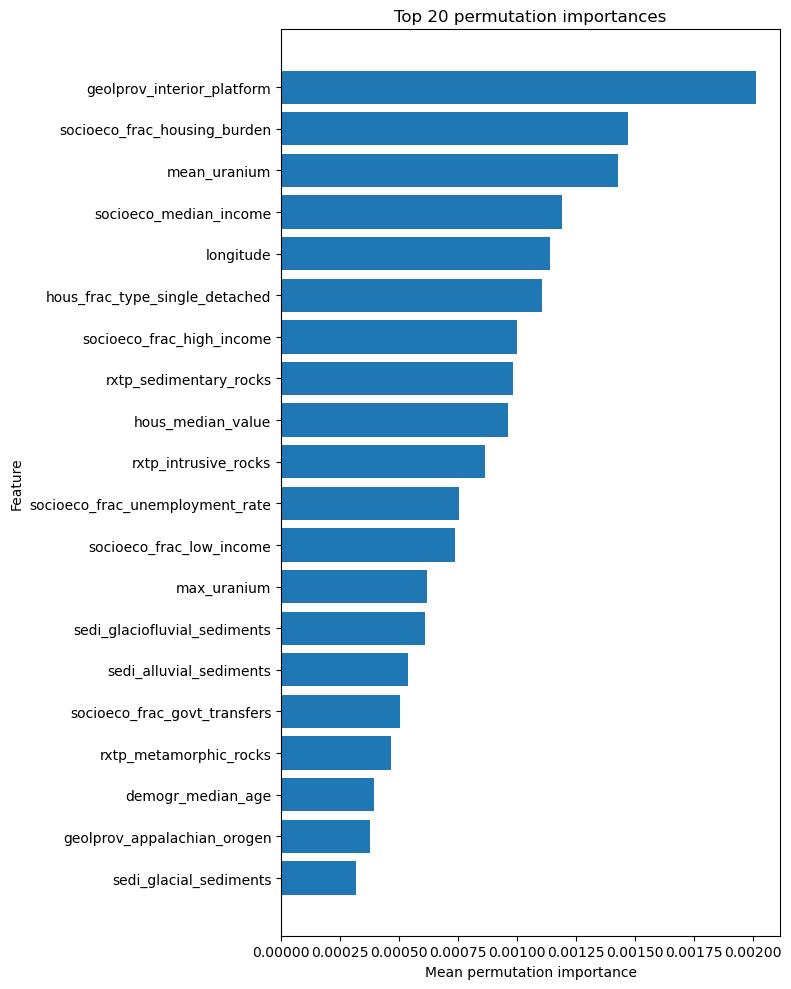

In [6]:
top_k = 20
plot_df = permutation_importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 10))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title("Top 20 permutation importances")
plt.tight_layout()
plt.show()

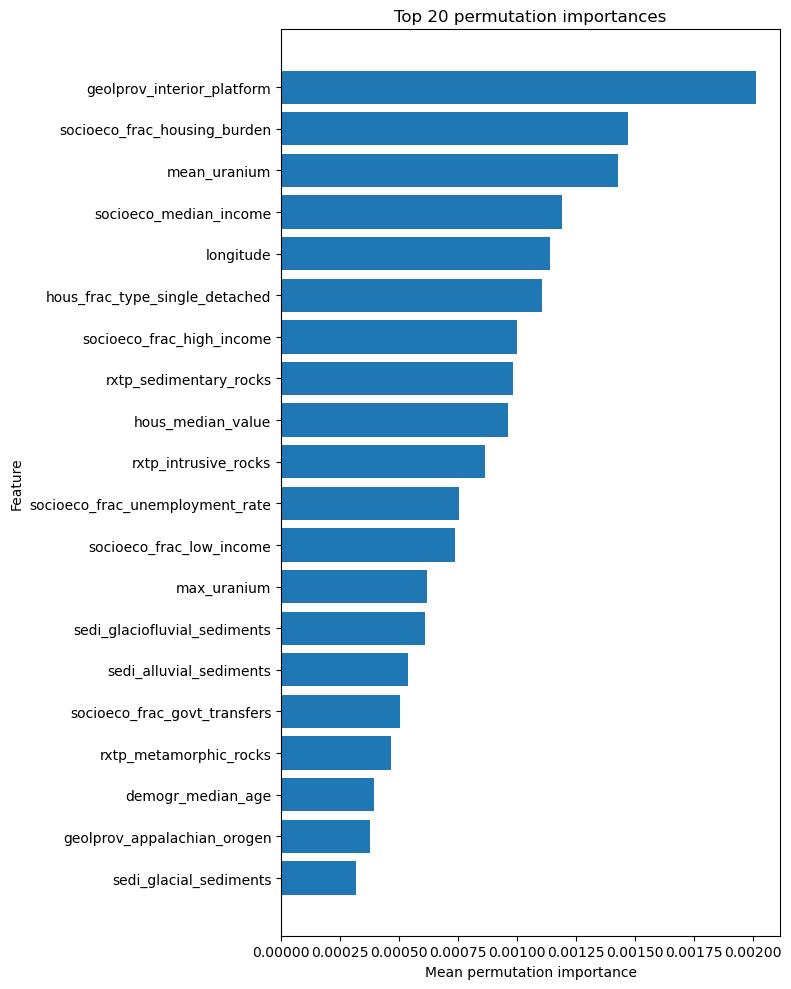

In [7]:
top_k = 20
plot_df = permutation_importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 10))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title("Top 20 permutation importances")
plt.tight_layout()
plt.show()

In [8]:

# ------------------------------------------------------------
# Categorize features by prefix / name
# ------------------------------------------------------------
def categorize_feature(feature_name: str) -> str:
    if feature_name in {"longitude", "latitude"}:
        return "Location"

    if "uranium" in feature_name.lower():
        return "Geology"

    if feature_name.startswith("geolprov_"):
        return "Geology"

    if feature_name.startswith("rxtp_"):
        return "Rock type"

    if feature_name.startswith("sedi_"):
        return "Geology"

    if feature_name.startswith("hous_"):
        return "Housing_infrastructure"

    if feature_name.startswith("socioeco_"):
        return "Socioeconomic"

    if feature_name.startswith("demogr_"):
        return "Demographic"

    if feature_name.startswith("clim_") or feature_name.startswith("weather_"):
        return "Housing_infrastructure"

    return "Other"

# ------------------------------------------------------------
# Optional: make labels shorter / nicer for slides
# ------------------------------------------------------------
def pretty_feature_name(feature_name: str) -> str:
    replacements = {
        "geolprov_": "",
        "rxtp_": "",
        "sedi_": "",
        "hous_": "",
        "socioeco_": "",
        "demogr_": "",
        "clim_": "",
    }

    pretty = feature_name
    for old, new in replacements.items():
        pretty = pretty.replace(old, new)

    pretty = pretty.replace("_", " ")
    return pretty

# ------------------------------------------------------------
# Color map by category
# ------------------------------------------------------------
category_to_color = {
    "Geologic province": "#4C78A8",
    "Rock type": "#72B7B2",
    "Sediment": "#54A24B",
    "Uranium": "#E45756",
    "Location": "#B279A2",
    "Housing": "#F58518",
    "Socioeconomic": "#FF9DA6",
    "Demographic": "#9D755D",
    "Climate": "#BAB0AC",
    "Other": "#7F7F7F",
}

# ------------------------------------------------------------
# Build top-10 table
# ------------------------------------------------------------
top_k = 10

top_features_df = (
    permutation_importance_df
    .head(top_k)
    .copy()
)

top_features_df["category"] = top_features_df["feature"].apply(categorize_feature)
top_features_df["pretty_feature"] = top_features_df["feature"].apply(pretty_feature_name)
top_features_df["color"] = top_features_df["category"].map(category_to_color)

# reverse for horizontal bar plot so strongest is on top visually
plot_df = top_features_df.iloc[::-1].copy()

plot_df

,feature,importance_mean,importance_std,category,pretty_feature,color
9,rxtp_intrusive_rocks,0.000863,0.000304,Rock type,intrusive rocks,#72B7B2
8,hous_median_value,0.000962,0.000345,Housing_infrastructure,median value,NaN
7,rxtp_sedimentary_rocks,0.000984,0.000295,Rock type,sedimentary rocks,#72B7B2
6,socioeco_frac_high_income,0.001000,0.000389,Socioeconomic,frac high income,#FF9DA6
5,hous_frac_type_single_detached,0.001108,0.000411,Housing_infrastructure,frac type single detached,NaN
4,longitude,0.001140,0.000304,Location,longitude,#B279A2
3,socioeco_median_income,0.001191,0.000483,Socioeconomic,median income,#FF9DA6
2,mean_uranium,0.001429,0.000365,Geology,mean uranium,NaN
1,socioeco_frac_housing_burden,0.001471,0.000706,Socioeconomic,frac housing burden,#FF9DA6
0,geolprov_interior_platform,0.002015,0.000695,Geology,interior platform,NaN


In [ ]:
9	rxtp_intrusive_rocks	- geology
8	hous_median_value - housing infrastructure
7	rxtp_sedimentary_rocks - geology
6	socioeco_frac_high_income - socieoeconomic
5	hous_frac_type_single_detached - housing infrastructure
4	longitude	 - location
3	socioeco_median_income - socioeconomic	
2	mean_uranium	- geology
1	socioeco_frac_housing_burden	- socioeconomic
0	geolprov_interior_platform	- geology


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Hard-coded top 10 features + categories
# ------------------------------------------------------------
top10_features_df = pd.DataFrame({
    "feature": [
        "rxtp_intrusive_rocks",
        "hous_median_value",
        "rxtp_sedimentary_rocks",
        "socioeco_frac_high_income",
        "hous_frac_type_single_detached",
        "longitude",
        "socioeco_median_income",
        "mean_uranium",
        "socioeco_frac_housing_burden",
        "geolprov_interior_platform",
    ],
    "importance_mean": [
        permutation_importance_df.loc[permutation_importance_df["feature"] == "rxtp_intrusive_rocks", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "hous_median_value", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "rxtp_sedimentary_rocks", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "socioeco_frac_high_income", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "hous_frac_type_single_detached", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "longitude", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "socioeco_median_income", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "mean_uranium", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "socioeco_frac_housing_burden", "importance_mean"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "geolprov_interior_platform", "importance_mean"].values[0],
    ],
    "importance_std": [
        permutation_importance_df.loc[permutation_importance_df["feature"] == "rxtp_intrusive_rocks", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "hous_median_value", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "rxtp_sedimentary_rocks", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "socioeco_frac_high_income", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "hous_frac_type_single_detached", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "longitude", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "socioeco_median_income", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "mean_uranium", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "socioeco_frac_housing_burden", "importance_std"].values[0],
        permutation_importance_df.loc[permutation_importance_df["feature"] == "geolprov_interior_platform", "importance_std"].values[0],
    ],
    "category": [
        "Geology",
        "Housing infrastructure",
        "Geology",
        "Socioeconomic",
        "Housing infrastructure",
        "Location",
        "Socioeconomic",
        "Geology",
        "Socioeconomic",
        "Geology",
    ]
})

top10_features_df

,feature,importance_mean,importance_std,category
0,rxtp_intrusive_rocks,0.000863,0.000304,Geology
1,hous_median_value,0.000962,0.000345,Housing infrastructure
2,rxtp_sedimentary_rocks,0.000984,0.000295,Geology
3,socioeco_frac_high_income,0.001000,0.000389,Socioeconomic
4,hous_frac_type_single_detached,0.001108,0.000411,Housing infrastructure
5,longitude,0.001140,0.000304,Location
6,socioeco_median_income,0.001191,0.000483,Socioeconomic
7,mean_uranium,0.001429,0.000365,Geology
8,socioeco_frac_housing_burden,0.001471,0.000706,Socioeconomic
9,geolprov_interior_platform,0.002015,0.000695,Geology


In [28]:
category_to_color = {
    "Geology": "#4C78A8",
    "Housing infrastructure": "#F58518",
    "Socioeconomic": "#E45756",
    "Location": "#72B7B2",
}

top10_features_df["color"] = top10_features_df["category"].map(category_to_color)

In [29]:
pretty_name_map = {
    "rxtp_intrusive_rocks": "Intrusive rocks",
    "hous_median_value": "Median home value",
    "rxtp_sedimentary_rocks": "Sedimentary rocks",
    "socioeco_frac_high_income": "High-income fraction",
    "hous_frac_type_single_detached": "Single-detached homes",
    "longitude": "Longitude",
    "socioeco_median_income": "Median income",
    "mean_uranium": "Mean uranium",
    "socioeco_frac_housing_burden": "Housing burden fraction",
    "geolprov_interior_platform": "Geol. Prov.: Interior platform",
}

top10_features_df["pretty_feature"] = top10_features_df["feature"].map(pretty_name_map)

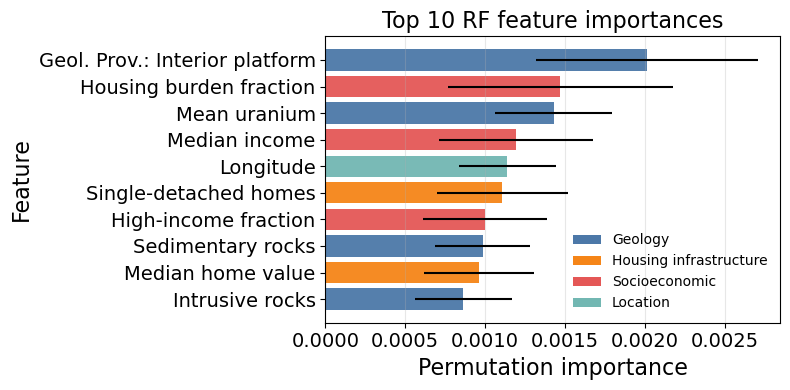

In [32]:
from matplotlib.patches import Patch
plot_df = top10_features_df.copy()

plt.figure(figsize=(8, 4))

plt.barh(
    plot_df["pretty_feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    color=plot_df["color"],
    edgecolor="none",
    alpha=0.95
)

plt.xlabel("Permutation importance", fontsize=16)
plt.ylabel("Feature", fontsize=16)
plt.title("Top 10 RF feature importances", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="x", alpha=0.3)

legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=category)
    for category, color in category_to_color.items()
]

plt.legend(
    handles=legend_handles,
    fontsize=10,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.show()